In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression


In [36]:
df = pd.read_csv("student_exam_data.csv")

In [37]:
df

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0
...,...,...,...
495,4.180170,45.494924,0
496,6.252905,95.038815,1
497,1.699612,48.209118,0
498,9.769553,97.014241,1


In [38]:
 model = LogisticRegression()

In [39]:
from sklearn.linear_model import LogisticRegression

# Features and target
X = df[['Study Hours']]
y = df['Pass/Fail']

# Initialize and fit
model = LogisticRegression()
model.fit(X, y)


LogisticRegression()

In [40]:
model.predict([[12.2]])

array([1])

In [41]:
# Predict class (0 = Fail, 1 = Pass)
print("Predicted class:", model.predict([[8.25]])[0])

# Predict probability
print("Probabilities:", model.predict_proba([[9.2]]))



Predicted class: 1
Probabilities: [[0.19620881 0.80379119]]


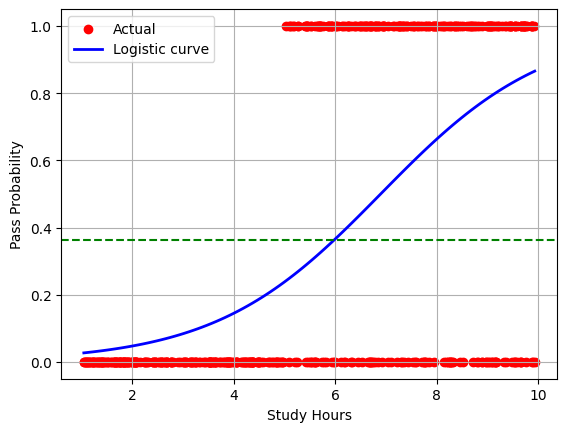

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a range of study hours
hours_range = np.linspace(df['Study Hours'].min(), df['Study Hours'].max(), 100).reshape(-1,1)

# Predicted probabilities
probs = model.predict_proba(hours_range)[:,1]

# Plot
plt.scatter(df['Study Hours'], y, color='red', label='Actual')
plt.plot(hours_range, probs, color='blue', linewidth=2, label='Logistic curve')
plt.xlabel('Study Hours')
plt.ylabel('Pass Probability')
plt.legend()
mean_prob = probs.mean()
plt.axhline(mean_prob, color='green', linestyle='--', label=f'Mean Probability = {mean_prob:.2f}')


plt.grid(True)

plt.show()


In [43]:
X_plot = np.linspace(0,12,300).reshape(-1,1)
X_plot

array([[ 0.        ],
       [ 0.04013378],
       [ 0.08026756],
       [ 0.12040134],
       [ 0.16053512],
       [ 0.2006689 ],
       [ 0.24080268],
       [ 0.28093645],
       [ 0.32107023],
       [ 0.36120401],
       [ 0.40133779],
       [ 0.44147157],
       [ 0.48160535],
       [ 0.52173913],
       [ 0.56187291],
       [ 0.60200669],
       [ 0.64214047],
       [ 0.68227425],
       [ 0.72240803],
       [ 0.76254181],
       [ 0.80267559],
       [ 0.84280936],
       [ 0.88294314],
       [ 0.92307692],
       [ 0.9632107 ],
       [ 1.00334448],
       [ 1.04347826],
       [ 1.08361204],
       [ 1.12374582],
       [ 1.1638796 ],
       [ 1.20401338],
       [ 1.24414716],
       [ 1.28428094],
       [ 1.32441472],
       [ 1.36454849],
       [ 1.40468227],
       [ 1.44481605],
       [ 1.48494983],
       [ 1.52508361],
       [ 1.56521739],
       [ 1.60535117],
       [ 1.64548495],
       [ 1.68561873],
       [ 1.72575251],
       [ 1.76588629],
       [ 1

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score


In [45]:
import pandas as pd
import numpy as np

# Creating a dataset representing Indian Corporate Scenario
data = {
    'Employee_ID': np.arange(1001, 1021),
    'Avg_Training_Score': [85, 45, 92, 60, 55, 95, 78, 40, 88, 62, 90, 50, 82, 48, 75, 58, 98, 42, 65, 80],
    'Projects_Completed': [5, 2, 6, 3, 2, 7, 4, 1, 6, 3, 5, 2, 5, 2, 4, 3, 8, 1, 3, 5],
    'Commute_Time_Min': [30, 90, 25, 60, 80, 20, 45, 100, 35, 75, 40, 85, 30, 95, 50, 70, 15, 110, 65, 55],
    'Work_Location': ['Bangalore', 'Gurgaon', 'Bangalore', 'Pune', 'Gurgaon', 'Bangalore', 'Pune',
                      'Gurgaon', 'Bangalore', 'Pune', 'Bangalore', 'Gurgaon', 'Pune', 'Gurgaon',
                      'Bangalore', 'Pune', 'Bangalore', 'Gurgaon', 'Pune', 'Bangalore'],
    # Introduce missing values in 'Last_Year_Rating' to simulate real HR data issues
    'Last_Year_Rating': [5, 2, 5, 3, 2, 5, 4, 1, 5, 3, None, 2, 4, None, 3, 3, 5, 1, 3, 4],
    'Promoted': [1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1] # 1 = Promoted, 0 = Not
}

df = pd.DataFrame(data)

# Save to CSV so students can learn how to load files
df.to_csv('appraisal_data.csv', index=False)
print("CSV file 'appraisal_data.csv' created successfully!")

CSV file 'appraisal_data.csv' created successfully!


In [46]:
df = pd.read_csv("appraisal_data.csv")

In [47]:
df

,Employee_ID,Avg_Training_Score,Projects_Completed,Commute_Time_Min,Work_Location,Last_Year_Rating,Promoted
0,1001,85,5,30,Bangalore,5.0,1
1,1002,45,2,90,Gurgaon,2.0,0
2,1003,92,6,25,Bangalore,5.0,1
3,1004,60,3,60,Pune,3.0,0
4,1005,55,2,80,Gurgaon,2.0,0
5,1006,95,7,20,Bangalore,5.0,1
6,1007,78,4,45,Pune,4.0,1
7,1008,40,1,100,Gurgaon,1.0,0
8,1009,88,6,35,Bangalore,5.0,1
9,1010,62,3,75,Pune,3.0,0


In [48]:
#EDA


<Axes: xlabel='Promoted', ylabel='Avg_Training_Score'>

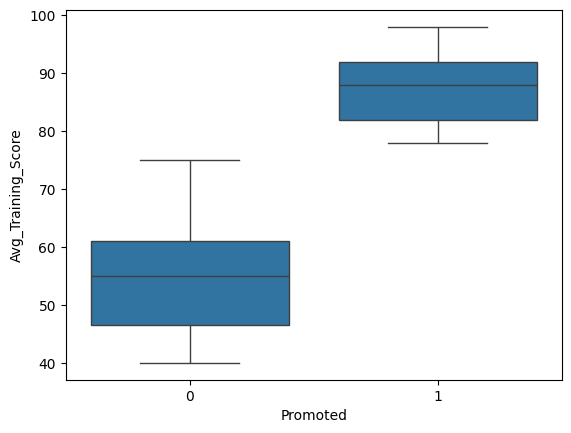

In [49]:
import seaborn as sns
sns.boxplot(x = 'Promoted', y= 'Avg_Training_Score', data = df)

In [50]:
#medain score of people promoted is higher to not promoted

<Axes: xlabel='Commute_Time_Min', ylabel='Count'>

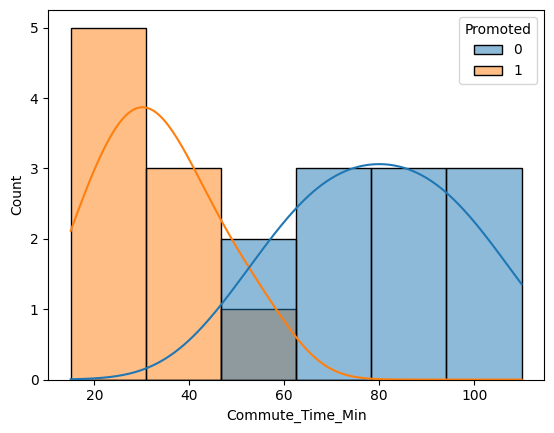

In [51]:
sns.histplot(x = 'Commute_Time_Min', hue = 'Promoted',data = df, kde  = True)

<Axes: xlabel='Commute_Time_Min', ylabel='Count'>

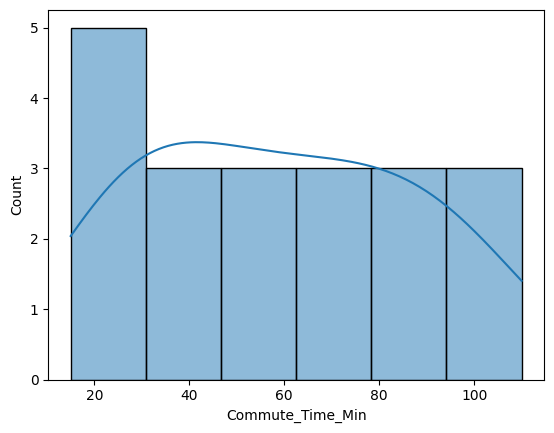

In [52]:
sns.histplot(x = 'Commute_Time_Min',data = df, kde  = True)
#majority pepople have less comuute time

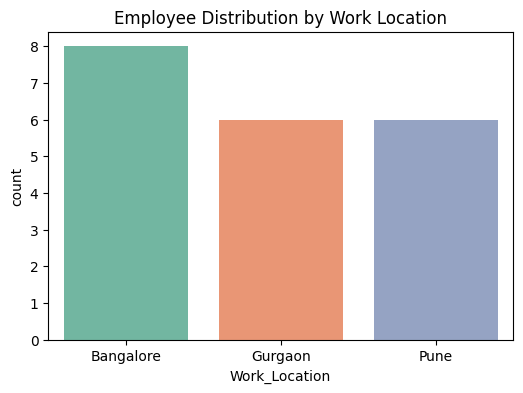

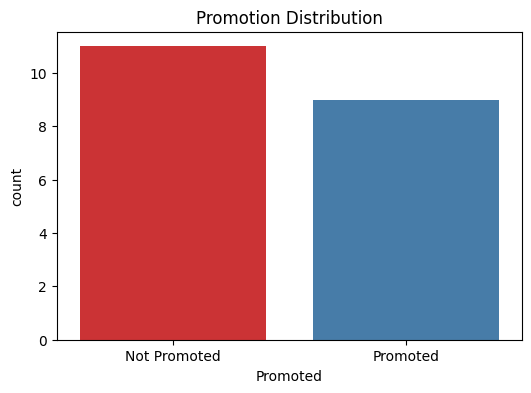

In [53]:

# Countplot of Work Location
plt.figure(figsize=(6,4))
sns.countplot(x='Work_Location', data=df, palette='Set2')
plt.title("Employee Distribution by Work Location")
plt.show()

# Promotion distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Promoted', data=df, palette='Set1')
plt.title("Promotion Distribution")
plt.xticks([0,1], ['Not Promoted','Promoted'])
plt.show()


# Data preprocessing

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         20 non-null     int64  
 1   Avg_Training_Score  20 non-null     int64  
 2   Projects_Completed  20 non-null     int64  
 3   Commute_Time_Min    20 non-null     int64  
 4   Work_Location       20 non-null     object 
 5   Last_Year_Rating    18 non-null     float64
 6   Promoted            20 non-null     int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 1.2+ KB


In [61]:
# Step 2: Handle missing values
df['Last_Year_Rating'] = df['Last_Year_Rating'].fillna(df['Last_Year_Rating'].median())

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

# Step 1: Load dataset
df = pd.read_csv('appraisal_data.csv')

# Step 2: Handle missing values
df['Last_Year_Rating'] = df['Last_Year_Rating'].fillna(df['Last_Year_Rating'].median())

# Step 3: Encode categorical variable
df = pd.get_dummies(df, columns=['Work_Location'], drop_first=True)


Confusion Matrix:
 [[3 0]
 [0 1]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [71]:
df

,Employee_ID,Avg_Training_Score,Projects_Completed,Commute_Time_Min,Last_Year_Rating,Promoted,Work_Location_Gurgaon,Work_Location_Pune
0,1001,85,5,30,5.0,1,False,False
1,1002,45,2,90,2.0,0,True,False
2,1003,92,6,25,5.0,1,False,False
3,1004,60,3,60,3.0,0,False,True
4,1005,55,2,80,2.0,0,True,False
5,1006,95,7,20,5.0,1,False,False
6,1007,78,4,45,4.0,1,False,True
7,1008,40,1,100,1.0,0,True,False
8,1009,88,6,35,5.0,1,False,False
9,1010,62,3,75,3.0,0,False,True


In [73]:
# Step: Remove outliers using IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Apply to numeric columns
numeric_cols = ['Avg_Training_Score','Projects_Completed','Commute_Time_Min','Last_Year_Rating']
df_clean = remove_outliers_iqr(df, numeric_cols)

print("Shape before:", df.shape)
print("Shape after removing outliers:", df_clean.shape)


Shape before: (20, 8)
Shape after removing outliers: (20, 8)


In [75]:
#feature engnieernig >> creating new features from existing feature
#efficiency ->
# Feature Engineering: Efficiency
df['Efficiency'] = df['Projects_Completed'] * df['Last_Year_Rating']


In [76]:
df

,Employee_ID,Avg_Training_Score,Projects_Completed,Commute_Time_Min,Last_Year_Rating,Promoted,Work_Location_Gurgaon,Work_Location_Pune,Efficiency
0,1001,85,5,30,5.0,1,False,False,25.0
1,1002,45,2,90,2.0,0,True,False,4.0
2,1003,92,6,25,5.0,1,False,False,30.0
3,1004,60,3,60,3.0,0,False,True,9.0
4,1005,55,2,80,2.0,0,True,False,4.0
5,1006,95,7,20,5.0,1,False,False,35.0
6,1007,78,4,45,4.0,1,False,True,16.0
7,1008,40,1,100,1.0,0,True,False,1.0
8,1009,88,6,35,5.0,1,False,False,30.0
9,1010,62,3,75,3.0,0,False,True,9.0


In [70]:

# Step 4: Define features (X) and target (y)
X = df.drop(['Employee_ID','Promoted'], axis=1)
y = df['Promoted']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 7: Train Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Step 8: Predictions
y_pred = model.predict(X_test)

# Step 9: Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[3 0]
 [0 1]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [78]:
model.coef_

array([[ 0.88159554,  0.75035866, -0.68127115,  0.8089835 , -0.15268471,
        -0.04445413]])